# Thunderstorm Prediction using CatBoost
Workflow:
1. EDA
2. Create Train/Validation/Test CSVs
3. Train CatBoost
4. Validation
5. Test Evaluation
6. Save Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("../Data")   # notebook is inside Notebooks folder

train_full = pd.read_csv(DATA_DIR/"UpperAir_Thunderstorm_Dataset_MetPy_Calculated_2000_2020.csv")
future = pd.read_csv(DATA_DIR/"UpperAir_Thunderstorm_Dataset_MetPy_Calculated_2021_2025.csv")

print(train_full.shape)
print(future.shape)
display(train_full.head())

(9619, 28)
(1972, 28)


,Date,Time,SI,LI,LI_V,SWEAT,KI,CT,VT,TT,...,BRN,BRN_V,LCL_T,LCL_P,THETAE_LCL,MML_PT,MML_MR,THK_1000_500,PW,Thunderstorm_24h
0,2000-01-01,00Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,290.303542,953.720426,331.599548,295.490326,8.322680,NaN,15.376751,0
1,2000-01-01,12Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,289.717396,907.460127,336.279548,299.196730,11.493170,NaN,16.683077,0
2,2000-01-02,00Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,288.557575,939.147482,327.626383,296.143662,11.262012,NaN,21.531383,0
3,2000-01-02,12Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,288.499752,893.270924,334.057380,296.573230,7.962237,NaN,18.986989,0
4,2000-01-03,00Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,286.176813,920.101660,322.604495,296.652747,7.619561,NaN,12.517480,0


<class 'pandas.DataFrame'>
RangeIndex: 9619 entries, 0 to 9618
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              9619 non-null   str    
 1   Time              9619 non-null   str    
 2   SI                8001 non-null   float64
 3   LI                8001 non-null   float64
 4   LI_V              8001 non-null   float64
 5   SWEAT             7584 non-null   float64
 6   KI                8001 non-null   float64
 7   CT                8001 non-null   float64
 8   VT                8001 non-null   float64
 9   TT                8001 non-null   float64
 10  CAPE              9588 non-null   float64
 11  CAPE_V            9588 non-null   float64
 12  CIN               9588 non-null   float64
 13  CIN_V             9588 non-null   float64
 14  EL                3551 non-null   float64
 15  EL_V              3274 non-null   float64
 16  LFC               7969 non-null   float64
 17  LFC_V 

EL_V                6345
EL                  6068
THK_1000_500        5680
BRN                 2354
BRN_V               2354
SWEAT               2035
LFC                 1650
TT                  1618
VT                  1618
LI                  1618
LI_V                1618
SI                  1618
CT                  1618
KI                  1618
LFC_V               1574
MML_PT                67
MML_MR                67
CIN                   31
CAPE_V                31
CAPE                  31
THETAE_LCL            31
LCL_P                 31
CIN_V                 31
LCL_T                 31
PW                    31
Date                   0
Time                   0
Thunderstorm_24h       0
dtype: int64


Target Distribution
Thunderstorm_24h
0    7674
1    1945
Name: count, dtype: int64


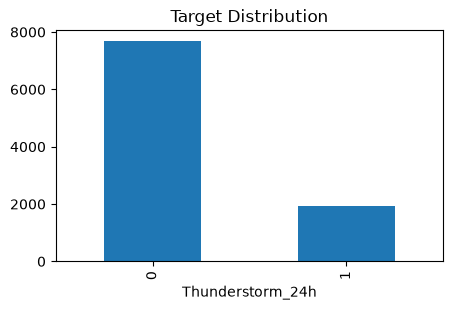

In [2]:
# ---------- QUICK EDA ----------
print(train_full.info())
print(train_full.describe(include="all"))

print("\nMissing Values")
display(train_full.isna().sum().sort_values(ascending=False))

print("\nTarget Distribution")
print(train_full["Thunderstorm_24h"].value_counts())

plt.figure(figsize=(5,3))
train_full["Thunderstorm_24h"].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.show()

In [3]:
# ---------- CREATE TRAIN / VALIDATION / TEST CSV ----------
train_full["Date"]=pd.to_datetime(train_full["Date"])
future["Date"]=pd.to_datetime(future["Date"])

validation=future[(future["Date"]>="2021-01-01")&(future["Date"]<="2022-12-31")].copy()
test=future[(future["Date"]>="2023-01-01")&(future["Date"]<="2025-12-31")].copy()

train_path=DATA_DIR/"train_2000_2020.csv"
val_path=DATA_DIR/"validation_2021_2022.csv"
test_path=DATA_DIR/"test_2023_2025.csv"

train_full.to_csv(train_path,index=False)
validation.to_csv(val_path,index=False)
test.to_csv(test_path,index=False)

print(train_full.shape,validation.shape,test.shape)
print("Saved CSV files successfully.")

(9619, 28) (580, 28) (1392, 28)
Saved CSV files successfully.


In [4]:
# ---------- CATBOOST TRAINING ----------
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score,f1_score

train=pd.read_csv(train_path)
val=pd.read_csv(val_path)
test=pd.read_csv(test_path)

drop_cols=["Thunderstorm_24h","Date","Time"]

X_train=train.drop(columns=drop_cols)
y_train=train["Thunderstorm_24h"]

X_val=val.drop(columns=drop_cols)
y_val=val["Thunderstorm_24h"]

X_test=test.drop(columns=drop_cols)
y_test=test["Thunderstorm_24h"]

model=CatBoostClassifier(
    iterations=1500,
    learning_rate=0.03,
    depth=8,
    loss_function="Logloss",
    eval_metric="F1",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=100
)

model.fit(
    X_train,y_train,
    eval_set=(X_val,y_val),
    use_best_model=True
)

val_pred=model.predict(X_val)
val_prob=model.predict_proba(X_val)[:,1]

print("Validation F1:",f1_score(y_val,val_pred))
print("Validation AUC:",roc_auc_score(y_val,val_prob))
print(confusion_matrix(y_val,val_pred))
print(classification_report(y_val,val_pred))

0:	learn: 0.7674181	test: 0.7209014	best: 0.7209014 (0)	total: 200ms	remaining: 4m 59s
100:	learn: 0.8080041	test: 0.7341378	best: 0.7540720 (1)	total: 3.73s	remaining: 51.6s
200:	learn: 0.8385760	test: 0.7457579	best: 0.7540720 (1)	total: 8.94s	remaining: 57.8s
300:	learn: 0.8663704	test: 0.7519535	best: 0.7563839 (269)	total: 13.9s	remaining: 55.5s
400:	learn: 0.8929325	test: 0.7337108	best: 0.7563839 (269)	total: 18.9s	remaining: 51.8s
500:	learn: 0.9178922	test: 0.7298524	best: 0.7563839 (269)	total: 23.8s	remaining: 47.5s
600:	learn: 0.9342279	test: 0.7229267	best: 0.7563839 (269)	total: 29.1s	remaining: 43.5s
700:	learn: 0.9488491	test: 0.7198663	best: 0.7563839 (269)	total: 34s	remaining: 38.8s
800:	learn: 0.9614302	test: 0.7126262	best: 0.7563839 (269)	total: 39.1s	remaining: 34.1s
900:	learn: 0.9696811	test: 0.7050531	best: 0.7563839 (269)	total: 44.2s	remaining: 29.4s
1000:	learn: 0.9774459	test: 0.6995873	best: 0.7563839 (269)	total: 49s	remaining: 24.4s
1100:	learn: 0.98293

In [5]:
# ---------- FINAL TEST ----------
test_pred=model.predict(X_test)
test_prob=model.predict_proba(X_test)[:,1]

print("Test F1:",f1_score(y_test,test_pred))
print("Test AUC:",roc_auc_score(y_test,test_prob))
print(confusion_matrix(y_test,test_pred))
print(classification_report(y_test,test_pred))

Test F1: 0.39111111111111113
Test AUC: 0.8053673294228663
[[849 370]
 [ 41 132]]
              precision    recall  f1-score   support

           0       0.95      0.70      0.81      1219
           1       0.26      0.76      0.39       173

    accuracy                           0.70      1392
   macro avg       0.61      0.73      0.60      1392
weighted avg       0.87      0.70      0.75      1392



,Feature,Importance
24,PW,10.131120
19,LCL_P,7.273761
21,MML_PT,5.728216
3,SWEAT,5.474544
4,KI,4.806911
23,THK_1000_500,4.574325
20,THETAE_LCL,4.424491
14,LFC,4.397168
22,MML_MR,4.056184
15,LFC_V,4.002364


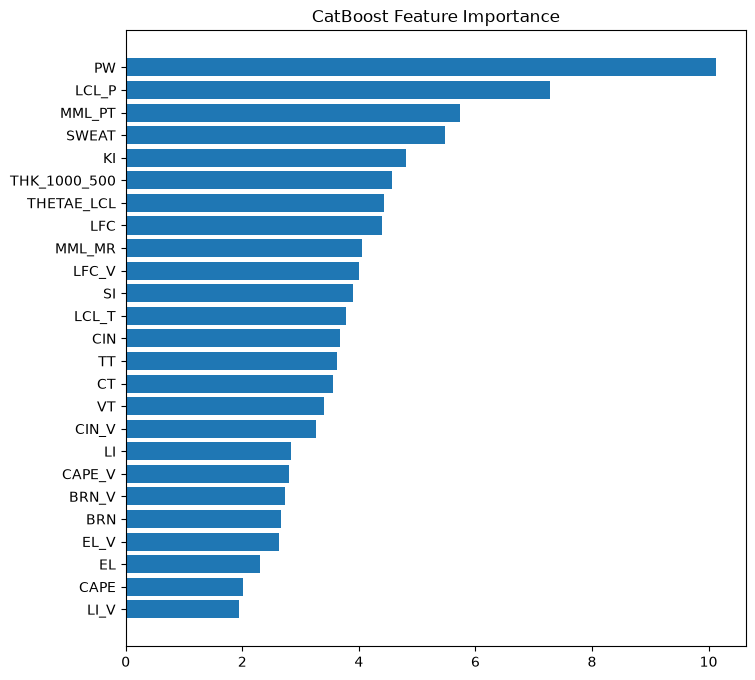

In [6]:
# ---------- FEATURE IMPORTANCE ----------
imp=pd.DataFrame({
    "Feature":X_train.columns,
    "Importance":model.get_feature_importance()
}).sort_values("Importance",ascending=False)

display(imp)

plt.figure(figsize=(8,8))
plt.barh(imp["Feature"],imp["Importance"])
plt.gca().invert_yaxis()
plt.title("CatBoost Feature Importance")
plt.show()

In [ ]:
# ---------- SAVE MODEL ----------
import joblib

joblib.dump(model,DATA_DIR/"catboost_thunderstorm_model.pkl")
print("Model saved successfully.")